In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2026-04-29 04:10:40.644040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777435840.836368      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777435840.894010      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777435841.369195      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777435841.369238      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777435841.369241      57 computation_placer.cc:177] computation placer alr

In [2]:
import os
BASE_PATH = "/kaggle/input/kaggle-hac-x-26-data-sprint-to-the-peak/eye_diseases_classification"
print(os.listdir(BASE_PATH))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/kaggle-hac-x-26-data-sprint-to-the-peak/eye_diseases_classification'

In [3]:
import os

# Find correct path
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    break  # just top level first

/kaggle/input


In [4]:
import os

for dirname, dirs, files in os.walk('/kaggle/input'):
    for d in dirs:
        print(os.path.join(dirname, d))
    break

/kaggle/input/competitions


In [5]:
import os

for dirname, dirs, files in os.walk('/kaggle/input/competitions'):
    for d in dirs:
        print(os.path.join(dirname, d))
    break

/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak


In [6]:
import os

BASE_PATH = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak"
print(os.listdir(BASE_PATH))

['EuroSAT', 'eye_diseases_classification', 'cassava_leaf_disease_classification', 'synthetic_industrial_metal_surface_defects']


In [7]:
BASE_PATH = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/eye_diseases_classification"
print(os.listdir(BASE_PATH))

['dataset']


In [8]:
import os
BASE_PATH = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/eye_diseases_classification/dataset"
print(os.listdir(BASE_PATH))

['glaucoma', 'normal', 'diabetic_retinopathy', 'cataract']


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

BASE_PATH = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/eye_diseases_classification/dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print("Classes:", train_gen.class_indices)
print("Train samples:", train_gen.samples)
print("Val samples:", val_gen.samples)

Found 3376 images belonging to 4 classes.
Found 841 images belonging to 4 classes.
Classes: {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}
Train samples: 3376
Val samples: 841


In [11]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(4, activation='softmax')(x)

model = Model(base_model.input, output)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model built successfully!")
model.summary()

I0000 00:00:1777436691.679666      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777436691.685602      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1777436871.347840     168 service.cc:152] XLA service 0x7c0614112690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777436871.347886     168 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777436871.347891     168 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777436873.666323     168 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-29 04:28:01.081015: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:28:01.225244: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:28:01.575666: E external/local_xl

 48/106 ━━━━━━━━━━━━━━━━━━━━ 38s 670ms/step - accuracy: 0.2514 - loss: 1.4387

2026-04-29 04:28:49.006812: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:28:49.147466: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:28:49.468301: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:28:49.609955: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:28:50.394760: E external/local_xla/xla/stream_

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.2512 - loss: 1.4323

2026-04-29 04:29:57.905238: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:29:58.042848: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:29:58.357467: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:29:58.499080: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:29:59.289622: E external/local_xla/xla/stream_

106/106 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.2511 - loss: 1.4322 - val_accuracy: 0.2604 - val_loss: 1.3858 - learning_rate: 0.0010
Epoch 2/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 64s 606ms/step - accuracy: 0.2481 - loss: 1.3907 - val_accuracy: 0.2604 - val_loss: 1.3864 - learning_rate: 0.0010
Epoch 3/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.2443 - loss: 1.3860
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
106/106 ━━━━━━━━━━━━━━━━━━━━ 64s 600ms/step - accuracy: 0.2443 - loss: 1.3860 - val_accuracy: 0.2545 - val_loss: 1.3860 - learning_rate: 0.0010
Epoch 4/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 64s 607ms/step - accuracy: 0.2565 - loss: 1.3867 - val_accuracy: 0.2604 - val_loss: 1.3859 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


In [13]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=3, factor=0.3, verbose=1)
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


2026-04-29 04:38:12.124939: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:38:12.277106: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 76/106 ━━━━━━━━━━━━━━━━━━━━ 15s 524ms/step - accuracy: 0.5349 - loss: 1.1471

2026-04-29 04:39:30.800801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:39:30.942508: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 04:39:31.085389: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


106/106 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.5769 - loss: 1.0552 - val_accuracy: 0.2616 - val_loss: 1.3924 - learning_rate: 1.0000e-04
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 66s 620ms/step - accuracy: 0.8407 - loss: 0.4328 - val_accuracy: 0.2473 - val_loss: 1.4124 - learning_rate: 1.0000e-04
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 65s 615ms/step - accuracy: 0.9031 - loss: 0.2921 - val_accuracy: 0.3793 - val_loss: 1.5169 - learning_rate: 1.0000e-04
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.9217 - loss: 0.2348
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
106/106 ━━━━━━━━━━━━━━━━━━━━ 65s 616ms/step - accuracy: 0.9217 - loss: 0.2347 - val_accuracy: 0.4447 - val_loss: 1.4024 - learning_rate: 1.0000e-04
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 65s 615ms/step - accuracy: 0.9141 - loss: 0.2082 - val_accuracy: 0.3769 - val_loss: 1.3407 - learning_rate: 3.0000e-05
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 66s 624ms/step - accurac

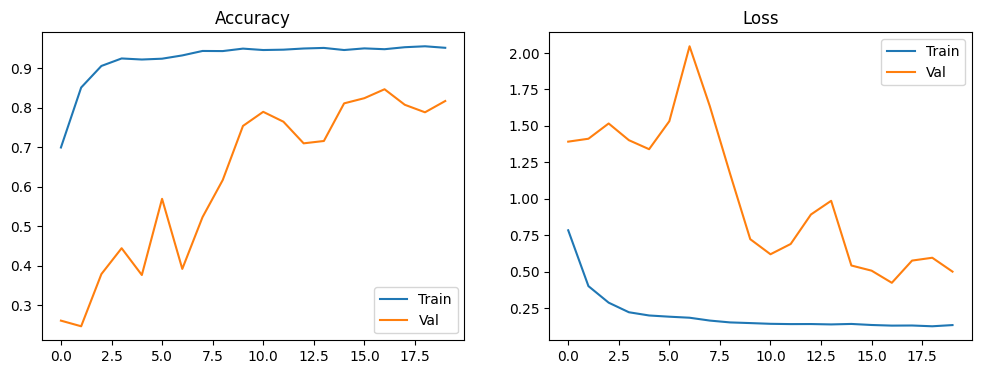

27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 596ms/step
                      precision    recall  f1-score   support

            cataract       0.23      0.24      0.24       207
diabetic_retinopathy       0.24      0.24      0.24       219
            glaucoma       0.22      0.16      0.19       201
              normal       0.25      0.31      0.28       214

            accuracy                           0.24       841
           macro avg       0.24      0.24      0.24       841
        weighted avg       0.24      0.24      0.24       841



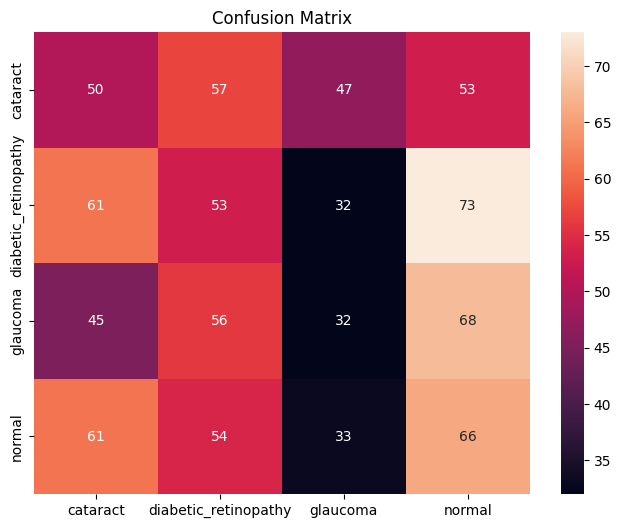

Model saved!


In [14]:
# Plot
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history2.history['accuracy'], label='Train')
plt.plot(history2.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history2.history['loss'], label='Train')
plt.plot(history2.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.savefig('training_curves.png')
plt.show()

# Evaluate
val_gen.reset()
preds = model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

# Save model
model.save('eye_disease_model.h5')
print("Model saved!")

Found 4217 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step

2026-04-29 05:09:11.774870: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 05:09:11.917736: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 05:09:12.257907: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 05:09:12.400090: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 05:09:13.183953: E external/local_xla/xla/stream_

132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 288ms/step
                      precision    recall  f1-score   support

            cataract       0.95      0.94      0.94      1038
diabetic_retinopathy       0.99      0.99      0.99      1098
            glaucoma       0.94      0.80      0.87      1007
              normal       0.83      0.95      0.89      1074

            accuracy                           0.92      4217
           macro avg       0.93      0.92      0.92      4217
        weighted avg       0.93      0.92      0.92      4217



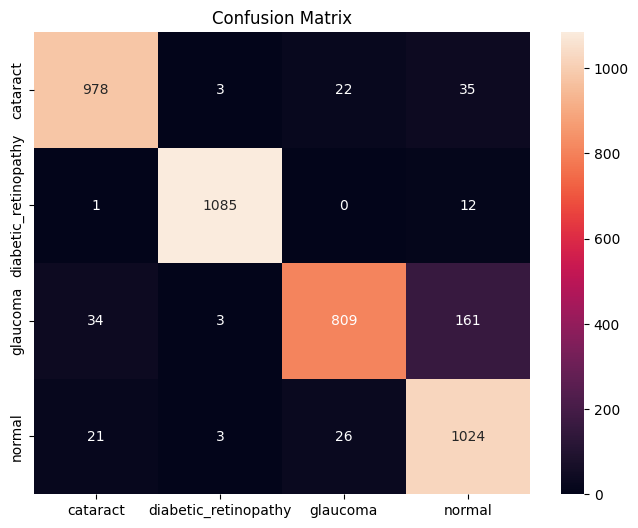

In [15]:
# Recreate val generator without shuffle
from tensorflow.keras.preprocessing.image import ImageDataGenerator

val_datagen = ImageDataGenerator(rescale=1./255)

val_gen_fixed = val_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Predict
preds = model.predict(val_gen_fixed)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen_fixed.classes
class_names = list(val_gen_fixed.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

In [16]:
from IPython.display import FileLink
FileLink('eye_disease_model.h5')

/kaggle/working/eye_disease_model.h5

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# Load your saved model
model = load_model('/kaggle/working/eye_disease_model.h5')

2026-04-29 06:16:34.270692: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777443394.812869      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777443395.010222      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777443396.259010      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777443396.259066      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777443396.259069      57 computation_placer.cc:177] computation placer alr

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/kaggle/working/eye_disease_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)